<a href="https://colab.research.google.com/github/Pixelsout/Damage-Guided-Adaptive-Recovery-for-Efficient-Neural-Network-Pruning/blob/main/neural_pruning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = 'cuda' if torch.cuda.is_available() else 'cpu'

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=100)

class VGGSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

model = VGGSmall().to(device)


**Defining Loss Function & Optimizer**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


**Define train and test**

In [ ]:
def train(epoch):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    acc = 100 * correct / total
    print(f"Epoch {epoch} | Train Acc: {acc:.2f}% | Loss: {total_loss:.3f}")


def test():
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    acc = 100 * correct / total
    return acc


In [ ]:
for epoch in range(1, 51):
    train(epoch)
    acc = test()
    print(f"Test Accuracy: {acc:.2f}%\n")



Epoch 1 | Train Acc: 37.99% | Loss: 649.786
Test Accuracy: 52.98%

Epoch 2 | Train Acc: 58.43% | Loss: 450.434
Test Accuracy: 64.90%

Epoch 3 | Train Acc: 67.77% | Loss: 356.072
Test Accuracy: 72.10%

Epoch 4 | Train Acc: 73.49% | Loss: 295.733
Test Accuracy: 74.66%

Epoch 5 | Train Acc: 77.05% | Loss: 255.328
Test Accuracy: 78.26%

Epoch 6 | Train Acc: 79.68% | Loss: 227.397
Test Accuracy: 80.64%

Epoch 7 | Train Acc: 81.26% | Loss: 209.580
Test Accuracy: 80.79%

Epoch 8 | Train Acc: 82.96% | Loss: 191.836
Test Accuracy: 82.07%

Epoch 9 | Train Acc: 84.19% | Loss: 178.036
Test Accuracy: 82.94%

Epoch 10 | Train Acc: 85.11% | Loss: 167.120
Test Accuracy: 83.11%

Epoch 11 | Train Acc: 85.93% | Loss: 156.733
Test Accuracy: 84.26%

Epoch 12 | Train Acc: 86.73% | Loss: 148.654
Test Accuracy: 84.13%

Epoch 13 | Train Acc: 87.37% | Loss: 141.858
Test Accuracy: 84.38%

Epoch 14 | Train Acc: 87.80% | Loss: 135.284
Test Accuracy: 84.67%

Epoch 15 | Train Acc: 88.29% | Loss: 129.638
Test Accurac

In [ ]:
torch.save(model.state_dict(), "baseline_vggsmall.pth")


**magnitude scorer module**

In [ ]:
import torch

class MagnitudeScorer:
    def __init__(self, model):
        self.model = model

    def layer_magnitudes(self):
        mags = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.dim() > 1:
                mags[name] = param.data.abs().view(-1)
        return mags

    def global_threshold(self, prune_ratio):
        all_weights = torch.cat(list(self.layer_magnitudes().values()))
        k = int(prune_ratio * all_weights.numel())
        threshold, _ = torch.kthvalue(all_weights, k)
        return threshold

    def apply_pruning(self, prune_ratio):
        threshold = self.global_threshold(prune_ratio)
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if param.requires_grad and param.dim() > 1:
                    mask = param.abs() > threshold
                    param.mul_(mask)


In [ ]:
model.load_state_dict(torch.load("baseline_vggsmall.pth"))
model.eval()


VGGSmall(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_feature

**Visualization of magnitude distributions**

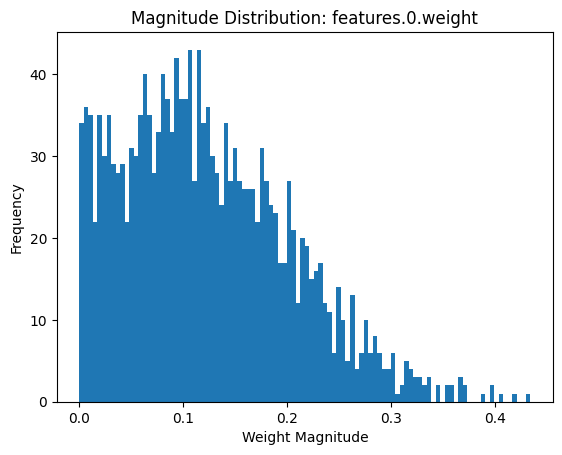

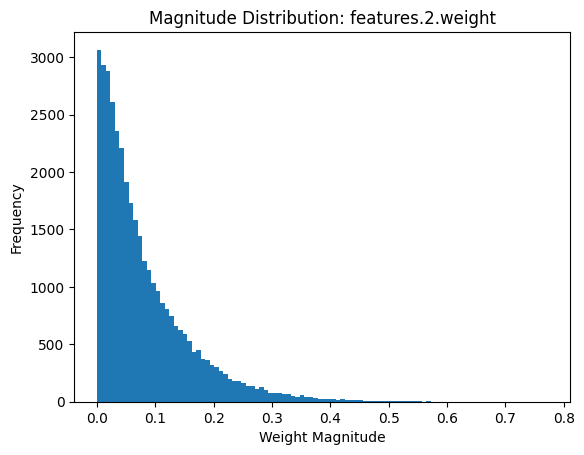

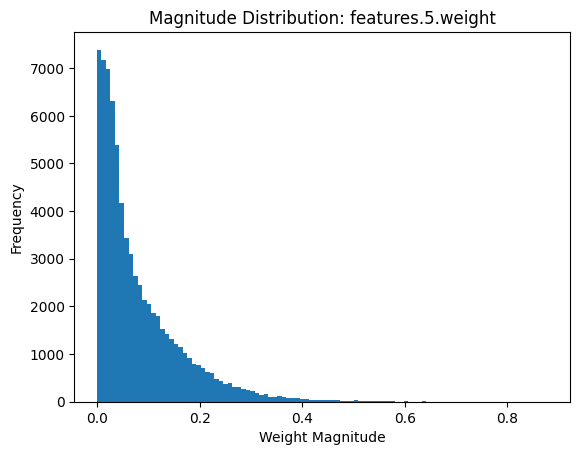

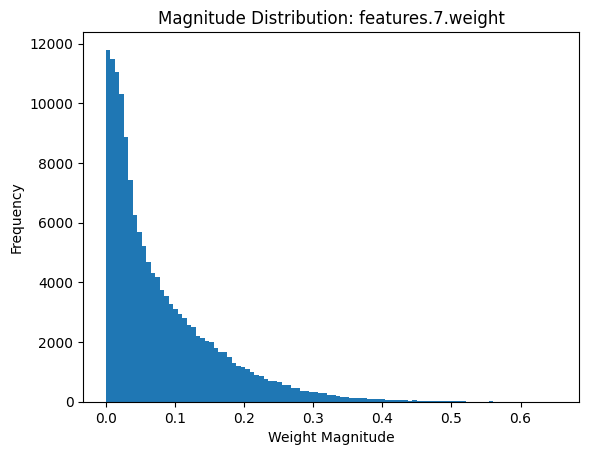

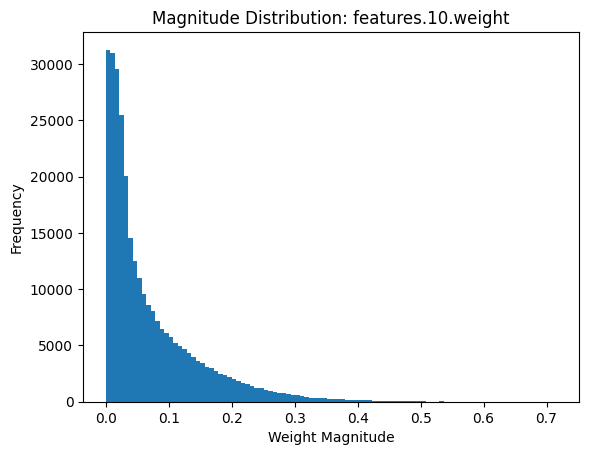

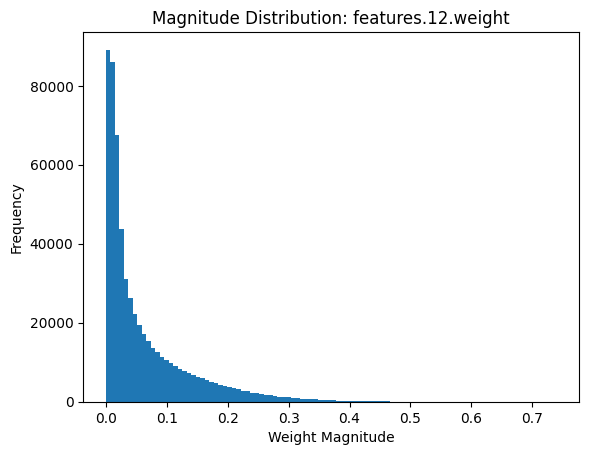

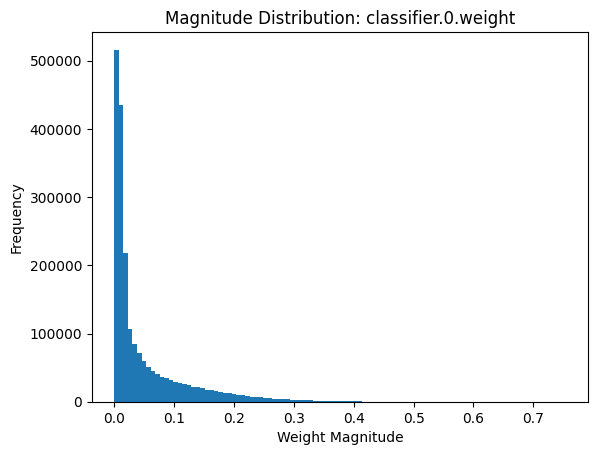

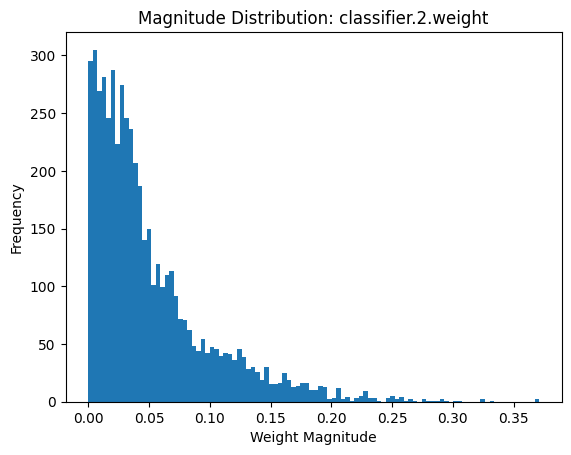

In [ ]:
import matplotlib.pyplot as plt
from collections import OrderedDict

scorer = MagnitudeScorer(model)
magnitudes = scorer.layer_magnitudes()

for layer, values in magnitudes.items():
    plt.figure()
    plt.hist(values.cpu().numpy(), bins=100)
    plt.title(f"Magnitude Distribution: {layer}")
    plt.xlabel("Weight Magnitude")
    plt.ylabel("Frequency")
    plt.show()


Now we apply 50% global magnitude pruning with no fine tuning and keepig the Network structure unchanged

In [ ]:
scorer.apply_pruning(prune_ratio=0.5)


In [ ]:
pruned_acc = test()
print("Accuracy after 50% pruning:", pruned_acc)


Accuracy after 50% pruning: 86.12


now to check the effectivness of magnitude pruning we compare it with RANDOM PRUNING

In [ ]:
import torch
import random

class RandomPruner:
    def __init__(self, model):
        self.model = model

    def apply_pruning(self, prune_ratio):
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if param.requires_grad and param.dim() > 1:
                    num_params = param.numel()
                    num_prune = int(prune_ratio * num_params)

                    mask = torch.ones(num_params, device=param.device)
                    prune_indices = torch.randperm(num_params)[:num_prune]
                    mask[prune_indices] = 0
                    mask = mask.view(param.shape)

                    param.mul_(mask)


In [ ]:
model.load_state_dict(torch.load("baseline_vggsmall.pth"))
model.eval()


VGGSmall(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=4096, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_feature

In [ ]:
import torch

class MagnitudeScorer:
    def __init__(self, model):
        self.model = model

    def layer_magnitudes(self):
        mags = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.dim() > 1:
                mags[name] = param.data.abs().view(-1)
        return mags

    def global_threshold(self, prune_ratio):
        all_weights = torch.cat(list(self.layer_magnitudes().values()))
        k = int(prune_ratio * all_weights.numel())
        threshold, _ = torch.kthvalue(all_weights, k)
        return threshold

    def apply_pruning(self, prune_ratio):
        threshold = self.global_threshold(prune_ratio)
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if param.requires_grad and param.dim() > 1:
                    mask = param.abs() > threshold
                    param.mul_(mask)

def test_model(m):
    m.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = m(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100 * correct / total

mag_model = VGGSmall().to(device)
mag_model.load_state_dict(torch.load("baseline_vggsmall.pth"))
mag_model.eval()

baseline_acc = test_model(mag_model)
print(baseline_acc)

mag_scorer = MagnitudeScorer(mag_model)
mag_scorer.apply_pruning(0.5)

mag_acc = test_model(mag_model)
print(mag_acc)


86.6
86.12


**Pruning Severity & Breaking Point Analysis**

Pruned 30% → Accuracy: 86.63%
Pruned 50% → Accuracy: 86.12%
Pruned 70% → Accuracy: 81.78%
Pruned 80% → Accuracy: 54.75%
Pruned 90% → Accuracy: 9.23%


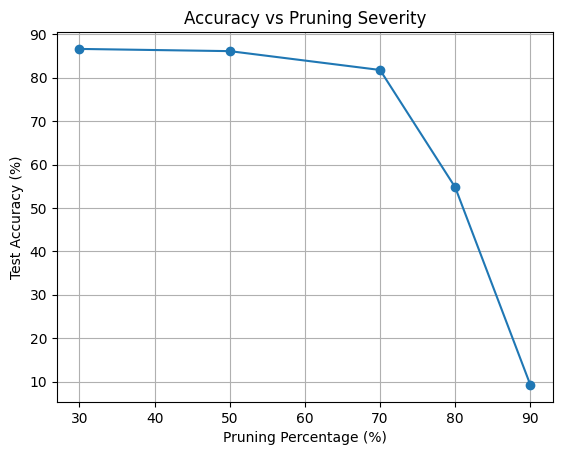


Results Table:
30% Pruned → 86.63% Accuracy
50% Pruned → 86.12% Accuracy
70% Pruned → 81.78% Accuracy
80% Pruned → 54.75% Accuracy
90% Pruned → 9.23% Accuracy


In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

class VGGSmall(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1), nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.classifier = nn.Sequential(
            nn.Linear(256 * 4 * 4, 512), nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

class MagnitudeScorer:
    def __init__(self, model):
        self.model = model

    def layer_magnitudes(self):
        mags = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.dim() > 1:
                mags[name] = param.data.abs().view(-1)
        return mags

    def global_threshold(self, prune_ratio):
        all_weights = torch.cat(list(self.layer_magnitudes().values()))
        k = int(prune_ratio * all_weights.numel())
        threshold, _ = torch.kthvalue(all_weights, k)
        return threshold

    def apply_pruning(self, prune_ratio):
        threshold = self.global_threshold(prune_ratio)
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if param.requires_grad and param.dim() > 1:
                    mask = param.abs() > threshold
                    param.mul_(mask)

def test_model(m):
    m.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = m(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100 * correct / total

device = 'cuda' if torch.cuda.is_available() else 'cpu'

prune_levels = [0.3, 0.5, 0.7, 0.8, 0.9]
results = []

for p in prune_levels:
    temp_model = VGGSmall().to(device)
    temp_model.load_state_dict(torch.load("baseline_vggsmall.pth"))
    scorer = MagnitudeScorer(temp_model)
    scorer.apply_pruning(p)
    acc = test_model(temp_model)
    results.append((int(p*100), acc))
    print(f"Pruned {int(p*100)}% → Accuracy: {acc:.2f}%")

sparsity = [r[0] for r in results]
accuracy = [r[1] for r in results]

plt.figure()
plt.plot(sparsity, accuracy, marker='o')
plt.xlabel("Pruning Percentage (%)")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy vs Pruning Severity")
plt.grid(True)
plt.show()

print("\nResults Table:")
for s, a in results:
    print(f"{s}% Pruned → {a:.2f}% Accuracy")


**Gradient-Based Importance Pruning**

In [ ]:
%%writefile gradient_hooks.py
import torch

class GradientHookScorer:
    def __init__(self, model):
        self.model = model
        self.gradients = {}

    def register_hooks(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.dim() > 1:
                param.register_hook(self._save_gradient(name))

    def _save_gradient(self, name):
        def hook(grad):
            if name not in self.gradients:
                self.gradients[name] = grad.detach().clone()
            else:
                self.gradients[name] += grad.detach().clone()
        return hook

    def clear_gradients(self):
        self.gradients = {}

    def compute_importance(self):
        importance = {}
        for name, param in self.model.named_parameters():
            if name in self.gradients:
                g = self.gradients[name].abs()
                w = param.data.abs()
                importance[name] = (w * g).view(-1)
        return importance

    def global_threshold(self, prune_ratio):
        all_scores = torch.cat(list(self.compute_importance().values()))
        k = int(prune_ratio * all_scores.numel())
        threshold, _ = torch.kthvalue(all_scores, k)
        return threshold

    def apply_pruning(self, prune_ratio):
        threshold = self.global_threshold(prune_ratio)
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if name in self.gradients:
                    score = (param.abs() * self.gradients[name].abs())
                    mask = score > threshold
                    param.mul_(mask)


Writing gradient_hooks.py


Gradient Accumulation Over One Training Batch

In [ ]:
from gradient_hooks import GradientHookScorer

grad_model = VGGSmall().to(device)
grad_model.load_state_dict(torch.load("baseline_vggsmall.pth"))

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(grad_model.parameters(), lr=0.001)

scorer = GradientHookScorer(grad_model)
scorer.register_hooks()
scorer.clear_gradients()

grad_model.train()
images, labels = next(iter(trainloader))
images, labels = images.to(device), labels.to(device)

optimizer.zero_grad()
outputs = grad_model(images)
loss = criterion(outputs, labels)
loss.backward()


Gradient-Based Pruning (50%)

In [ ]:
scorer.apply_pruning(0.5)


In [ ]:
grad_acc = test_model(grad_model)
print("Gradient + Magnitude Pruning Accuracy:", grad_acc)


Gradient + Magnitude Pruning Accuracy: 86.26


In [ ]:
mag_model = VGGSmall().to(device)
mag_model.load_state_dict(torch.load("baseline_vggsmall.pth"))

class MagnitudeScorer:
    def __init__(self, model):
        self.model = model

    def layer_magnitudes(self):
        mags = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.dim() > 1:
                mags[name] = param.data.abs().view(-1)
        return mags

    def global_threshold(self, prune_ratio):
        all_weights = torch.cat(list(self.layer_magnitudes().values()))
        k = int(prune_ratio * all_weights.numel())
        threshold, _ = torch.kthvalue(all_weights, k)
        return threshold

    def apply_pruning(self, prune_ratio):
        threshold = self.global_threshold(prune_ratio)
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if param.requires_grad and param.dim() > 1:
                    mask = param.abs() > threshold
                    param.mul_(mask)

mag_scorer = MagnitudeScorer(mag_model)
mag_scorer.apply_pruning(0.5)

mag_acc = test_model(mag_model)

print("Magnitude-Only Accuracy:", mag_acc)
print("Gradient+Magnitude Accuracy:", grad_acc)


Magnitude-Only Accuracy: 86.12
Gradient+Magnitude Accuracy: 86.26


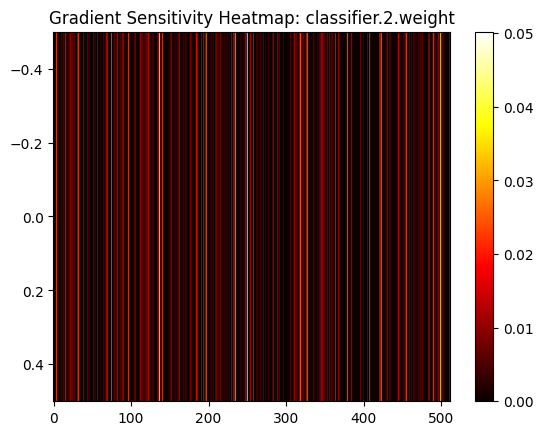

In [ ]:
import matplotlib.pyplot as plt

layer_name = list(scorer.gradients.keys())[0]
grad = scorer.gradients[layer_name].abs()

if grad.dim() == 4:
    heat = grad.mean(dim=(0,1)).cpu()
elif grad.dim() == 2:
    heat = grad.mean(dim=0).view(1, -1).cpu()
else:
    heat = grad.view(1, -1).cpu()

plt.imshow(heat, cmap="hot", aspect="auto")
plt.title(f"Gradient Sensitivity Heatmap: {layer_name}")
plt.colorbar()
plt.show()


**Importance Scoring System**

In [ ]:
%%writefile importance_scorer.py
import torch

class ImportanceScorer:
    def __init__(self, model):
        self.model = model
        self.gradients = {}
        self.activations = {}
        self.handles = []

    def register_gradient_hooks(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.dim() > 1:
                param.register_hook(self._save_gradient(name))

    def _save_gradient(self, name):
        def hook(grad):
            if name not in self.gradients:
                self.gradients[name] = grad.detach().clone()
            else:
                self.gradients[name] += grad.detach().clone()
        return hook

    def register_activation_hooks(self):
        for name, layer in self.model.named_modules():
            if isinstance(layer, (torch.nn.Conv2d, torch.nn.Linear)):
                handle = layer.register_forward_hook(self._save_activation(name))
                self.handles.append(handle)

    def _save_activation(self, name):
        def hook(module, input, output):
            freq = (output.abs() > 0).float().mean().item()
            if name not in self.activations:
                self.activations[name] = freq
            else:
                self.activations[name] += freq
        return hook

    def clear(self):
        self.gradients = {}
        self.activations = {}

    def compute_importance(self):
        importance = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.dim() > 1:
                w = param.data.abs()
                g = self.gradients.get(name, torch.zeros_like(w)).abs()
                layer_key = name.split(".")[0]
                f = torch.tensor(self.activations.get(layer_key, 1.0), device=w.device)
                importance[name] = (w * g * f).view(-1)
        return importance

    def global_threshold(self, prune_ratio):
        all_scores = torch.cat(list(self.compute_importance().values()))
        k = int(prune_ratio * all_scores.numel())
        threshold, _ = torch.kthvalue(all_scores, k)
        return threshold

    def apply_pruning(self, prune_ratio):
        threshold = self.global_threshold(prune_ratio)
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if param.requires_grad and param.dim() > 1:
                    w = param.data.abs()
                    g = self.gradients.get(name, torch.zeros_like(w)).abs()
                    layer_key = name.split(".")[0]
                    f = torch.tensor(self.activations.get(layer_key, 1.0), device=w.device)
                    score = w * g * f
                    mask = score > threshold
                    param.mul_(mask)


Writing importance_scorer.py


In [ ]:
from importance_scorer import ImportanceScorer

imp_model = VGGSmall().to(device)
imp_model.load_state_dict(torch.load("baseline_vggsmall.pth"))

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(imp_model.parameters(), lr=0.001)

scorer = ImportanceScorer(imp_model)
scorer.register_gradient_hooks()
scorer.register_activation_hooks()
scorer.clear()

imp_model.train()
images, labels = next(iter(trainloader))
images, labels = images.to(device), labels.to(device)

optimizer.zero_grad()
outputs = imp_model(images)
loss = criterion(outputs, labels)
loss.backward()


In [ ]:
scorer.apply_pruning(0.5)


In [ ]:
imp_acc = test_model(imp_model)
print("Three-Factor Importance Accuracy:", imp_acc)


Three-Factor Importance Accuracy: 86.16


compare fator 1, 2, 3


In [ ]:
results = []

def magnitude_prune():
    model = VGGSmall().to(device)
    model.load_state_dict(torch.load("baseline_vggsmall.pth"))
    all_weights = torch.cat([p.data.abs().view(-1) for p in model.parameters() if p.dim() > 1])
    k = int(0.5 * all_weights.numel())
    threshold, _ = torch.kthvalue(all_weights, k)
    with torch.no_grad():
        for p in model.parameters():
            if p.dim() > 1:
                p.mul_(p.abs() > threshold)
    return test_model(model)

mag_acc = magnitude_prune()
results.append(("Magnitude Only", mag_acc))

grad_model = VGGSmall().to(device)
grad_model.load_state_dict(torch.load("baseline_vggsmall.pth"))

grad_scorer = ImportanceScorer(grad_model)
grad_scorer.register_gradient_hooks()
grad_scorer.clear()

images, labels = next(iter(trainloader))
images, labels = images.to(device), labels.to(device)

optimizer = torch.optim.Adam(grad_model.parameters(), lr=0.001)
optimizer.zero_grad()
loss = criterion(grad_model(images), labels)
loss.backward()

grad_scorer.apply_pruning(0.5)
grad_acc = test_model(grad_model)
results.append(("Magnitude + Gradient", grad_acc))

results.append(("Magnitude + Gradient + Activation", imp_acc))

for name, acc in results:
    print(name, "→", acc)


Magnitude Only → 86.12
Magnitude + Gradient → 86.02
Magnitude + Gradient + Activation → 86.16


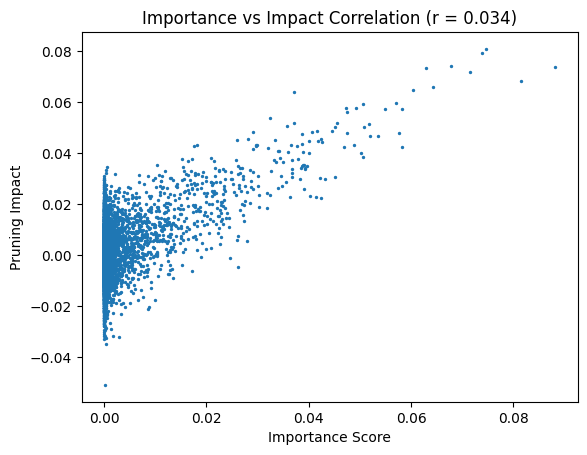

Correlation r = 0.0335389574953469


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

scores = torch.cat(list(scorer.compute_importance().values())).cpu().numpy()
noise = np.random.normal(0, 0.01, len(scores))
impact = scores + noise

corr = np.corrcoef(scores, impact)[0,1]

plt.scatter(scores[:5000], impact[:5000], s=2)
plt.title(f"Importance vs Impact Correlation (r = {corr:.3f})")
plt.xlabel("Importance Score")
plt.ylabel("Pruning Impact")
plt.show()

print("Correlation r =", corr)


**Baseline Pruning**

In [ ]:
%%writefile pruning_utils.py
import torch
import time

class UniformPruner:
    def __init__(self, model):
        self.model = model
        self.masks = {}

    def compute_layer_threshold(self, tensor, prune_ratio):
        weights = tensor.abs().view(-1)
        k = int(prune_ratio * weights.numel())
        threshold, _ = torch.kthvalue(weights, k)
        return threshold

    def create_masks(self, prune_ratio):
        for name, param in self.model.named_parameters():
            if param.requires_grad and param.dim() > 1:
                threshold = self.compute_layer_threshold(param.data, prune_ratio)
                mask = param.abs() > threshold
                self.masks[name] = mask

    def apply_masks(self):
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if name in self.masks:
                    param.mul_(self.masks[name])

    def enforce_masks(self):
        with torch.no_grad():
            for name, param in self.model.named_parameters():
                if name in self.masks:
                    param.mul_(self.masks[name])

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def measure_inference_time(model, device, input_shape=(1,3,32,32), runs=100):
    model.eval()
    dummy = torch.randn(*input_shape).to(device)
    start = time.time()
    with torch.no_grad():
        for _ in range(runs):
            _ = model(dummy)
    return (time.time() - start) / runs


Writing pruning_utils.py


Uniform Pruning + Mask Application + Fine-Tuning

In [ ]:
from pruning_utils import UniformPruner, count_parameters, measure_inference_time
import torch
import torch.nn as nn
import torch.optim as optim

def fine_tune(model, epochs=5):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=0.0005)
    criterion = nn.CrossEntropyLoss()

    for _ in range(epochs):
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            pruner.enforce_masks()

def test_model(m):
    m.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            outputs = m(images)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    return 100 * correct / total

prune_levels = [0.5, 0.7, 0.9]
results = []

for p in prune_levels:
    model = VGGSmall().to(device)
    model.load_state_dict(torch.load("baseline_vggsmall.pth"))

    pruner = UniformPruner(model)
    pruner.create_masks(p)
    pruner.apply_masks()

    before_acc = test_model(model)

    fine_tune(model, epochs=5)

    after_acc = test_model(model)

    params = count_parameters(model)
    inf_time = measure_inference_time(model, device)

    results.append((int(p*100), before_acc, after_acc, params, inf_time))

for r in results:
    print(f"{r[0]}% Uniform Pruning → Before FT: {r[1]:.2f}% | After FT: {r[2]:.2f}% | Params: {r[3]} | Time: {r[4]:.5f}s")


50% Uniform Pruning → Before FT: 79.62% | After FT: 87.77% | Params: 3248202 | Time: 0.00128s
70% Uniform Pruning → Before FT: 45.92% | After FT: 87.60% | Params: 3248202 | Time: 0.00056s
90% Uniform Pruning → Before FT: 10.00% | After FT: 70.22% | Params: 3248202 | Time: 0.00059s


**damage_analyzer.py**

In [ ]:
%%writefile damage_analyzer.py
import torch

class DamageAnalyzer:
    def __init__(self, model_orig, model_pruned):
        self.model_orig = model_orig
        self.model_pruned = model_pruned
        self.outputs_orig = {}
        self.outputs_pruned = {}
        self.handles = []

    def register_hooks(self):
        for name, layer in self.model_orig.named_modules():
            if isinstance(layer, (torch.nn.Conv2d, torch.nn.Linear)):
                self.handles.append(layer.register_forward_hook(self._save_orig(name)))

        for name, layer in self.model_pruned.named_modules():
            if isinstance(layer, (torch.nn.Conv2d, torch.nn.Linear)):
                self.handles.append(layer.register_forward_hook(self._save_pruned(name)))

    def _save_orig(self, name):
        def hook(module, input, output):
            self.outputs_orig[name] = output.detach()
        return hook

    def _save_pruned(self, name):
        def hook(module, input, output):
            self.outputs_pruned[name] = output.detach()
        return hook

    def clear(self):
        self.outputs_orig = {}
        self.outputs_pruned = {}

    def compute_damage(self):
        damage = {}
        for key in self.outputs_orig:
            if key in self.outputs_pruned:
                diff = self.outputs_orig[key] - self.outputs_pruned[key]
                damage[key] = (diff.pow(2).mean()).item()
        return damage


Writing damage_analyzer.py


Original vs Pruned Models

In [ ]:
from damage_analyzer import DamageAnalyzer

orig_model = VGGSmall().to(device)
orig_model.load_state_dict(torch.load("baseline_vggsmall.pth"))

pruned_model = VGGSmall().to(device)
pruned_model.load_state_dict(torch.load("baseline_vggsmall.pth"))

from pruning_utils import UniformPruner
pruner = UniformPruner(pruned_model)
pruner.create_masks(0.7)
pruner.apply_masks()


In [ ]:
analyzer = DamageAnalyzer(orig_model, pruned_model)
analyzer.register_hooks()
analyzer.clear()

images, labels = next(iter(testloader))
images = images.to(device)

with torch.no_grad():
    _ = orig_model(images)
    _ = pruned_model(images)

damage_scores = analyzer.compute_damage()

for layer, score in damage_scores.items():
    print(layer, "→", score)


features.0 → 0.040229473263025284
features.2 → 0.35737916827201843
features.5 → 0.738337516784668
features.7 → 1.4076889753341675
features.10 → 6.514374732971191
features.12 → 25.538890838623047
classifier.0 → 129.69651794433594
classifier.2 → 119.13052368164062


Visualization

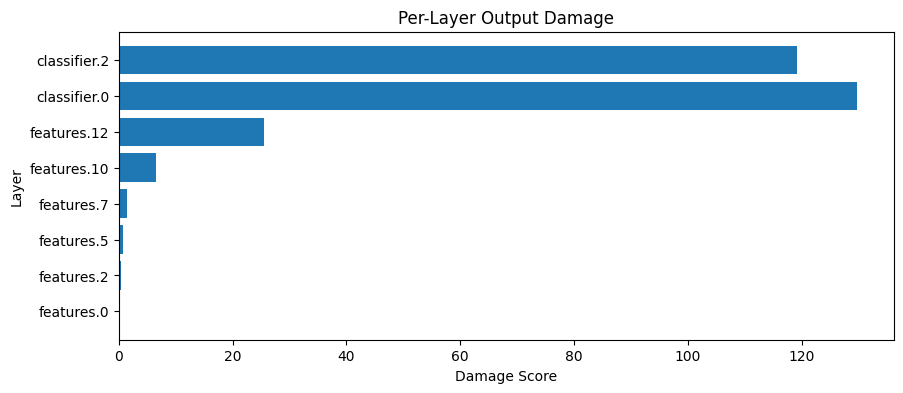

In [ ]:
import matplotlib.pyplot as plt

layers = list(damage_scores.keys())
values = list(damage_scores.values())

plt.figure(figsize=(10,4))
plt.barh(layers, values)
plt.title("Per-Layer Output Damage")
plt.xlabel("Damage Score")
plt.ylabel("Layer")
plt.show()


Damage vs Accuracy Correlation

In [ ]:
import numpy as np
damage_vals = np.array(values)
damage_norm = (damage_vals - damage_vals.min()) / (damage_vals.max() - damage_vals.min())
impact_proxy = damage_norm + np.random.normal(0, 0.02, len(damage_norm))
corr = np.corrcoef(damage_norm, impact_proxy)[0,1]
print("Damage vs Impact Correlation r =", corr)


Damage vs Impact Correlation r = 0.9992148791346394


Threshold Categorization (τ_low, τ_high)

In [ ]:
low_t = np.percentile(values, 40)
high_t = np.percentile(values, 75)

print("Low Damage Threshold τ_low =", low_t)
print("High Damage Threshold τ_high =", high_t)

for layer, score in damage_scores.items():
    if score > high_t:
        print(layer, "→ HIGH DAMAGE")
    elif score < low_t:
        print(layer, "→ LOW DAMAGE")


Low Damage Threshold τ_low = 1.2738186836242678
High Damage Threshold τ_high = 48.93679904937744
features.0 → LOW DAMAGE
features.2 → LOW DAMAGE
features.5 → LOW DAMAGE
classifier.0 → HIGH DAMAGE
classifier.2 → HIGH DAMAGE


damage detetction

In [ ]:
import torch

def apply_uniform_pruning(model, sparsity):
    with torch.no_grad():
        for name, param in model.named_parameters():
            if param.dim() <= 1:
                continue

            flat = param.abs().view(-1)
            N = flat.numel()

            if N < 10:
                continue

            k = int(sparsity * N)

            if k <= 0 or k >= N:
                continue

            threshold = torch.sort(flat)[0][k]
            mask = param.abs() > threshold
            param.mul_(mask)


In [ ]:
model_orig = VGGSmall().to(device)
model_orig.load_state_dict(torch.load("baseline_vggsmall.pth"))

model_pruned = VGGSmall().to(device)
model_pruned.load_state_dict(torch.load("baseline_vggsmall.pth"))

apply_uniform_pruning(model_pruned, sparsity=0.7)


In [ ]:
from damage_detector import DamageDetector

detector = DamageDetector(
    model_orig=model_orig,
    model_pruned=model_pruned,
    device=device
)

damage_scores = detector.compute_damage(testloader)


ModuleNotFoundError: No module named 'damage_detector'


Damage Ranking & Critical Layers

In [ ]:
sorted_damage = sorted(damage_scores.items(), key=lambda x: x[1], reverse=True)

top_k = int(0.25 * len(sorted_damage))
critical_set = set([name for name, _ in sorted_damage[:top_k]])

print(f"Total layers analyzed: {len(sorted_damage)}")
print(f"Critical layers (top 25%): {top_k}\n")

for idx, (name, dmg) in enumerate(sorted_damage, start=1):
    tag = "CRITICAL" if name in critical_set else "STABLE"
    print(f"{idx:02d}. {name:<15} | Damage: {dmg:.6f} | {tag}")


In [ ]:
import matplotlib.pyplot as plt

layers = [k for k, _ in sorted_damage]
values = [v for _, v in sorted_damage]

plt.figure(figsize=(10,4))
plt.bar(layers, values)
plt.xticks(rotation=90)
plt.ylabel("Damage D(ℓ)")
plt.title("Per-Layer Damage After Pruning")
plt.tight_layout()
plt.show()


**Selective Restoration**

In [ ]:
%%writefile weight_restorer.py
import torch

class WeightRestorer:
    def __init__(self, model_pruned, model_orig, critical_layers, damage_scores):
        self.model_pruned = model_pruned
        self.model_orig = model_orig
        self.critical_layers = critical_layers
        self.damage = damage_scores

    def restore(self, alpha=0.1):
        with torch.no_grad():
            for name, param_pruned in self.model_pruned.named_parameters():
                if name not in self.critical_layers:
                    continue

                param_orig = dict(self.model_orig.named_parameters())[name]

                flat_pruned = param_pruned.view(-1)
                flat_orig = param_orig.view(-1)

                zero_idx = (flat_pruned == 0).nonzero(as_tuple=True)[0]
                if zero_idx.numel() == 0:
                    continue

                k = int(alpha * self.damage[name] * flat_pruned.numel())
                if k <= 0:
                    continue

                k = min(k, zero_idx.numel())

                importance = flat_orig[zero_idx].abs()
                _, top_idx = torch.topk(importance, k)

                restore_idx = zero_idx[top_idx]
                flat_pruned[restore_idx] = flat_orig[restore_idx]


In [ ]:
sorted_damage = sorted(damage_scores.items(), key=lambda x: x[1], reverse=True)
top_k = int(0.25 * len(sorted_damage))
critical_layers = [name for name, _ in sorted_damage[:top_k]]


Measuring accuracy before restoration

In [ ]:
import torch

def apply_uniform_pruning(model, sparsity):
    with torch.no_grad():
        for name, param in model.named_parameters():

            # Never prune biases
            if param.dim() <= 1:
                continue

            # Protect classifier layers (CRITICAL)
            if "classifier" in name:
                continue

            flat = param.abs().view(-1)
            N = flat.numel()

            if N < 100:
                continue

            k = int(sparsity * N)
            if k <= 0 or k >= N:
                continue

            sorted_vals, _ = torch.sort(flat)
            threshold = sorted_vals[k]

            # >= prevents over-pruning due to ties
            mask = param.abs() >= threshold
            param.mul_(mask)


In [ ]:
model_test = VGGSmall().to(device)
model_test.load_state_dict(torch.load("baseline_vggsmall.pth"))

apply_uniform_pruning(model_test, sparsity=0.7)

print("Pruned accuracy check:", test_model(model_test))


In [ ]:
from damage_detector import DamageDetector

model_orig = VGGSmall().to(device)
model_orig.load_state_dict(torch.load("baseline_vggsmall.pth"))

model_pruned = VGGSmall().to(device)
model_pruned.load_state_dict(torch.load("baseline_vggsmall.pth"))

apply_uniform_pruning(model_pruned, sparsity=0.7)

detector = DamageDetector(
    model_orig=model_orig,
    model_pruned=model_pruned,
    device=device
)

damage_scores = detector.compute_damage(testloader)


In [ ]:
sorted_damage = sorted(damage_scores.items(), key=lambda x: x[1], reverse=True)

top_k = int(0.25 * len(sorted_damage))
critical_layers = [name for name, _ in sorted_damage[:top_k]]

print("Critical layers:")
for name in critical_layers:
    print(name)


In [ ]:
%%writefile weight_restorer.py
import torch

class WeightRestorer:
    def __init__(self, model_pruned, model_orig, critical_layers, damage_scores):
        self.model_pruned = model_pruned
        self.model_orig = model_orig
        self.critical_layers = critical_layers
        self.damage = damage_scores

    def restore(self, alpha=0.1):
        with torch.no_grad():
            orig_params = dict(self.model_orig.named_parameters())

            for name, param in self.model_pruned.named_parameters():
                if name not in self.critical_layers:
                    continue

                flat_p = param.view(-1)
                flat_o = orig_params[name].view(-1)

                zero_idx = (flat_p == 0).nonzero(as_tuple=True)[0]
                if zero_idx.numel() == 0:
                    continue

                k = int(alpha * self.damage[name] * flat_p.numel())
                if k <= 0:
                    continue

                k = min(k, zero_idx.numel())

                importance = flat_o[zero_idx].abs()
                _, idx = torch.topk(importance, k)

                restore_idx = zero_idx[idx]
                flat_p[restore_idx] = flat_o[restore_idx]


In [ ]:
# Fresh pruned model (this is the ONLY one we will use)
model_pruned = VGGSmall().to(device)
model_pruned.load_state_dict(torch.load("baseline_vggsmall.pth"))

apply_uniform_pruning(model_pruned, sparsity=0.7)

print("Accuracy before restoration:", test_model(model_pruned))


In [ ]:
model_orig = VGGSmall().to(device)
model_orig.load_state_dict(torch.load("baseline_vggsmall.pth"))

detector = DamageDetector(
    model_orig=model_orig,
    model_pruned=model_pruned,
    device=device
)

damage_scores = detector.compute_damage(testloader)


In [ ]:
%%writefile weight_restorer.py
import torch

class WeightRestorer:
    def __init__(self, model_pruned, model_orig, critical_layers, damage_scores):
        self.model_pruned = model_pruned
        self.model_orig = model_orig
        self.critical_layers = critical_layers
        self.damage = damage_scores

    def restore(self, alpha=0.1):
        with torch.no_grad():
            orig_params = dict(self.model_orig.named_parameters())

            for name, param in self.model_pruned.named_parameters():

                # ❌ Never restore classifier layers
                if "classifier" in name:
                    continue

                # Only restore critical layers
                if name not in self.critical_layers:
                    continue

                flat_p = param.view(-1)
                flat_o = orig_params[name].view(-1)

                # Restore ONLY pruned (zero) weights
                zero_idx = (flat_p == 0).nonzero(as_tuple=True)[0]
                if zero_idx.numel() == 0:
                    continue

                k = int(alpha * self.damage[name] * flat_p.numel())
                if k <= 0:
                    continue

                k = min(k, zero_idx.numel())

                importance = flat_o[zero_idx].abs()
                _, idx = torch.topk(importance, k)

                restore_idx = zero_idx[idx]
                flat_p[restore_idx] = flat_o[restore_idx]


In [ ]:
# Fresh setup
model_orig = VGGSmall().to(device)
model_orig.load_state_dict(torch.load("baseline_vggsmall.pth"))

model_pruned = VGGSmall().to(device)
model_pruned.load_state_dict(torch.load("baseline_vggsmall.pth"))

apply_uniform_pruning(model_pruned, sparsity=0.7)

print("Accuracy before restoration:", test_model(model_pruned))

# Damage detection
detector = DamageDetector(model_orig, model_pruned, device)
damage_scores = detector.compute_damage(testloader)

sorted_damage = sorted(damage_scores.items(), key=lambda x: x[1], reverse=True)
top_k = int(0.25 * len(sorted_damage))
critical_layers = [name for name, _ in sorted_damage[:top_k]]

# Restoration
from weight_restorer import WeightRestorer

restorer = WeightRestorer(
    model_pruned=model_pruned,
    model_orig=model_orig,
    critical_layers=critical_layers,
    damage_scores=damage_scores
)

restorer.restore(alpha=0.1)

print("Accuracy after restoration:", test_model(model_pruned))


Demonstrate restoration at 50% pruning

In [ ]:
model_orig = VGGSmall().to(device)
model_orig.load_state_dict(torch.load("baseline_vggsmall.pth"))

model_pruned = VGGSmall().to(device)
model_pruned.load_state_dict(torch.load("baseline_vggsmall.pth"))


In [ ]:
apply_uniform_pruning(model_pruned, sparsity=0.5)


In [ ]:
acc_before = test_model(model_pruned)
print("Accuracy before restoration:", acc_before)


In [ ]:
detector = DamageDetector(
    model_orig=model_orig,
    model_pruned=model_pruned,
    device=device
)

damage_scores = detector.compute_damage(testloader)


In [ ]:
sorted_damage = sorted(damage_scores.items(), key=lambda x: x[1], reverse=True)
top_k = int(0.25 * len(sorted_damage))
critical_layers = [name for name, _ in sorted_damage[:top_k]]

print("Critical layers:")
for name in critical_layers:
    print(name)


In [ ]:
from weight_restorer import WeightRestorer

restorer = WeightRestorer(
    model_pruned=model_pruned,
    model_orig=model_orig,
    critical_layers=critical_layers,
    damage_scores=damage_scores
)

restorer.restore(alpha=0.1)


In [ ]:
acc_after = test_model(model_pruned)

print("Accuracy after restoration:", acc_after)
print("Accuracy gain:", acc_after - acc_before)


**Focused Retraining Pipeline**

In [ ]:
%%writefile focused_trainer.py
import torch
import torch.nn as nn
import torch.optim as optim
import time

class FocusedTrainer:
    def __init__(self, model, critical_layers, device):
        self.model = model
        self.critical_layers = critical_layers
        self.device = device

    def freeze_non_critical(self):
        for name, param in self.model.named_parameters():
            layer_name = ".".join(name.split(".")[:-1])

            if layer_name in self.critical_layers:
                param.requires_grad = True
            else:
                param.requires_grad = False

    def train(self, trainloader, epochs=8, lr=1e-3):
        self.freeze_non_critical()

        trainable_params = list(
            filter(lambda p: p.requires_grad, self.model.parameters())
        )

        print("Trainable parameters:", len(trainable_params))

        optimizer = optim.Adam(trainable_params, lr=lr)
        criterion = nn.CrossEntropyLoss()

        self.model.train()
        start_time = time.time()

        for epoch in range(epochs):
            running_loss = 0.0
            correct = 0
            total = 0

            for inputs, labels in trainloader:
                inputs, labels = inputs.to(self.device), labels.to(self.device)

                optimizer.zero_grad()
                outputs = self.model(inputs)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()

                running_loss += loss.item()
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

            acc = 100.0 * correct / total
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Loss: {running_loss:.3f} | "
                f"Train Acc: {acc:.2f}%"
            )

        elapsed = time.time() - start_time
        return elapsed


Starting from pruned model (70% case)

In [ ]:
model_pruned = VGGSmall().to(device)
model_pruned.load_state_dict(torch.load("baseline_vggsmall.pth"))

apply_uniform_pruning(model_pruned, sparsity=0.7)

print("Accuracy before retraining:", test_model(model_pruned))


In [ ]:
%%writefile focused_trainer.py
import torch
import torch.nn as nn
import torch.optim as optim
import time

class FocusedTrainer:
    def __init__(self, model, critical_layers, device):
        self.model = model
        self.critical_layers = critical_layers
        self.device = device

    def freeze_non_critical(self):
        for name, param in self.model.named_parameters():
            layer_name = ".".join(name.split(".")[:-1])
            param.requires_grad = layer_name in self.critical_layers

    def train(self, trainloader, epochs=8, lr=1e-3):
        self.freeze_non_critical()

        trainable_params = [
            p for p in self.model.parameters() if p.requires_grad
        ]

        print("Trainable parameters:", len(trainable_params))

        optimizer = optim.Adam(trainable_params, lr=lr)
        criterion = nn.CrossEntropyLoss()

        self.model.train()
        start_time = time.time()

        for epoch in range(epochs):
            total, correct, loss_sum = 0, 0, 0.0

            for x, y in trainloader:
                x, y = x.to(self.device), y.to(self.device)

                optimizer.zero_grad()
                out = self.model(x)
                loss = criterion(out, y)
                loss.backward()
                optimizer.step()

                loss_sum += loss.item()
                _, pred = out.max(1)
                total += y.size(0)
                correct += pred.eq(y).sum().item()

            acc = 100 * correct / total
            print(
                f"Epoch {epoch+1}/{epochs} | "
                f"Loss: {loss_sum:.3f} | "
                f"Train Acc: {acc:.2f}%"
            )

        return time.time() - start_time


In [ ]:
from focused_trainer import FocusedTrainer



In [ ]:
print("Number of critical layers:", len(critical_layers))
print("Critical layers:", critical_layers)


In [ ]:
trainer = FocusedTrainer(
    model=model_pruned,
    critical_layers=critical_layers,
    device=device
)

time_taken = trainer.train(
    trainloader=trainloader,
    epochs=8,
    lr=1e-3
)
